Malgun Gothic


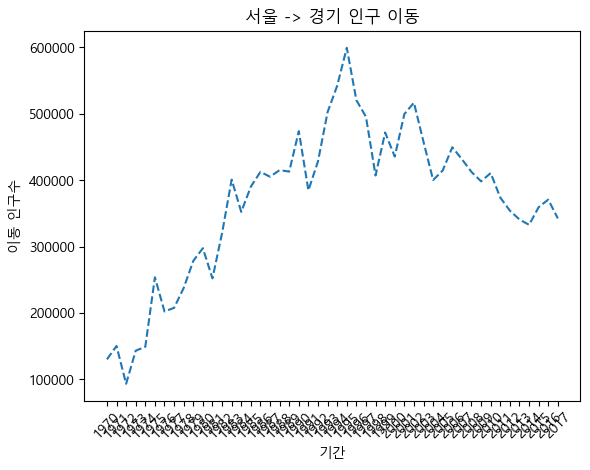

In [ ]:
# 라이브러리 불러오기
import pandas as pd
import matplotlib.pyplot as plt # 폰트관련 기능, 폰트를 수정할려면 이기능이 필요하다.

# matplotlib 한글 폰트 오류 문제 해결
from matplotlib import font_manager, rc
font_path = "./data/malgun.ttf"   # 폰트파일의 위치
                                  # Windows - Fonts
font_name = font_manager.FontProperties(fname=font_path).get_name()
# .get_name() : 폰트가 시스템에서 인식하는 이름을 가져옵니다.
# get_name() → .ttf 파일에서 폰트 이름(패밀리명) 추출
# 그 이름을 family에 넣으면 → matplotlib이 해당 폰트를 기본으로 사용
print(font_name) # Malgun Gothic
rc('font', family=font_name)

# Excel 데이터를 데이터프레임 변환 
df = pd.read_excel('./data/시도별_전출입_인구수.xlsx')

# 누락값(NaN)을 앞 데이터로 채움 (엑셀 양식 병합 부분)
df = df.ffill()

# 서울에서 다른 지역으로 이동한 데이터만 추출하여 정리
mask = (df['전출지별'] == '서울특별시') & (df['전입지별'] != '서울특별시') 
df_seoul = df[mask]
df_seoul = df_seoul.drop(['전출지별'], axis=1)
df_seoul = df_seoul.rename({'전입지별':'전입지'}, axis=1)
df_seoul = df_seoul.set_index('전입지')

# 서울에서 경기도로 이동한 인구 데이터 값만 선택 
sr_one = df_seoul.loc['경기도']

# x, y축 데이터를 plot 함수에 입력
plt.plot(sr_one.index, sr_one.values,linestyle='--')
# plt.plot(sr_one.values,sr_one.index) # ^ T

# 차트 제목 추가
plt.title('서울 -> 경기 인구 이동')

# 글의 기울기
plt.xticks(rotation = 45)
# 축이름 추가
plt.xlabel('기간')
plt.ylabel('이동 인구수')

plt.show()  # 변경사항 저장하고 그래프 출력